## Modelamiento

En este notebook probamos diferentes modelos, analizamos la importancia de las variables y elegimos el modelo que estará a cargo de dar las predicciones.

In [1]:
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

### Carga de datos

In [2]:
# Cargamos los datos limpios
df = pd.read_csv('/Users/alberth/Documents/Proyectos/credit_risk/data/processed.csv')
df.head()

,id,edad,ingresos,genero,estado_civil,num_hijos,num_tarjetas,modalidad_pago,hipoteca,prestamos,riesgo
0,100756,46,59944,M,Casado,1,2,Mensual,Si,0,0
1,100668,67,59692,F,Casado,1,1,Mensual,Si,0,0
2,100418,50,59508,M,Casado,1,1,Mensual,Si,1,0
3,100416,24,59463,M,Casado,0,2,Mensual,Si,1,0
4,100590,34,59393,F,Casado,0,2,Mensual,Si,0,0


### Preparación

In [3]:
# semilla 
seed = 42
random.seed(seed)
np.random.seed(seed)

In [4]:
# separamos la variable objetivo (Eliminamos ID y Genero)
X = df.drop(columns=['id','riesgo','genero'])
y = df.riesgo

In [5]:
# Particion de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.3, stratify=y, random_state=seed)

In [6]:
# Definimos el cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

### Logistic Regression

In [7]:
# Pipeline de preprocesamiento
num_cols = X.select_dtypes(['number']).columns.to_list()
cat_cols = X.select_dtypes(['str','category']).columns.to_list()

numerical_transformer_LogReg = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())])

categorical_transformer_LogReg = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))
])

preprocessor_LogReg = ColumnTransformer(
    transformers=[
    ('num', numerical_transformer_LogReg, num_cols),
    ('cat', categorical_transformer_LogReg, cat_cols)],
    remainder='passthrough')

In [8]:
pipeline_LogReg = Pipeline([
    ('preprocessor', preprocessor_LogReg),
    ('classifier', LogisticRegression(max_iter=1000, solver='saga', class_weight='balanced', random_state=seed))
])

In [9]:
param_grid_LogReg = {'classifier__C': [0.01, 0.1, 1, 10],
                     'classifier__l1_ratio': [0.0, 0.5, 1.0]}

logistic_model = GridSearchCV(estimator= pipeline_LogReg, 
                              param_grid= param_grid_LogReg, 
                              cv= cv,
                              scoring='roc_auc',
                              n_jobs=-1)

In [10]:
logistic_model.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ver='saga'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.01, 0.1, ...], 'classifier__l1_ratio': [0.0, 0.5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: in

In [11]:
print(f"Mejores parámetros: {logistic_model.best_params_}")

Mejores parámetros: {'classifier__C': 0.1, 'classifier__l1_ratio': 0.0}


In [12]:
resultados_cv_LogReg = pd.DataFrame(logistic_model.cv_results_)
mejor_fila = resultados_cv_LogReg.loc[logistic_model.best_index_]

print(f"ROBUSTEZ DEL MODELO LOGÍSTICO (Basado en {logistic_model.n_splits_} Folds)\n")
print(f"Rouc-Auc (Promedio): {mejor_fila['mean_test_score']:.2f}")
print(f"Desviación Estándar: {mejor_fila['std_test_score']:.2f}")

ROBUSTEZ DEL MODELO LOGÍSTICO (Basado en 5 Folds)

Rouc-Auc (Promedio): 0.74
Desviación Estándar: 0.01


Graficamos la curva roc sobre el conjunto de prueba

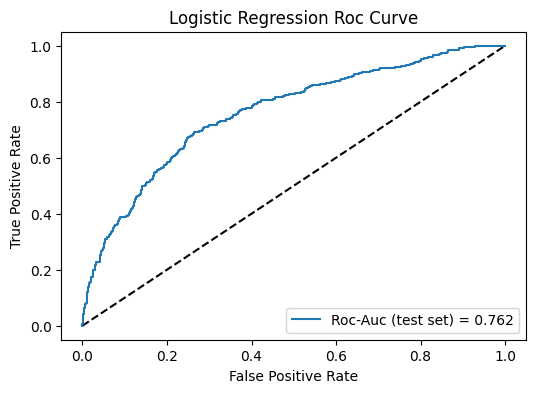

In [13]:
y_test_pred_probs = logistic_model.predict_proba(X_test)[:,1]
fpr, tpr, umbrales = roc_curve(y_test, y_test_pred_probs)

plt.figure(figsize=(6,4))
plt.plot([0,1],[0,1],'k--')
plt.plot(fpr,tpr, label= f'Roc-Auc (test set) = {auc(fpr, tpr):.3f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression Roc Curve')
plt.legend(loc='lower right')
plt.show()

#### Feature Importance

Calculamos la importancia según el método de permutación

In [14]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    logistic_model.best_estimator_, 
    X_test, 
    y_test, 
    n_repeats=10, 
    random_state=seed, 
    scoring='roc_auc'
)

# Creamos el DataFrame con los resultados
importancia = pd.DataFrame({
    'Variable': X_test.columns,
    'Importancia': result.importances_mean
}).sort_values(by='Importancia', ascending=True)

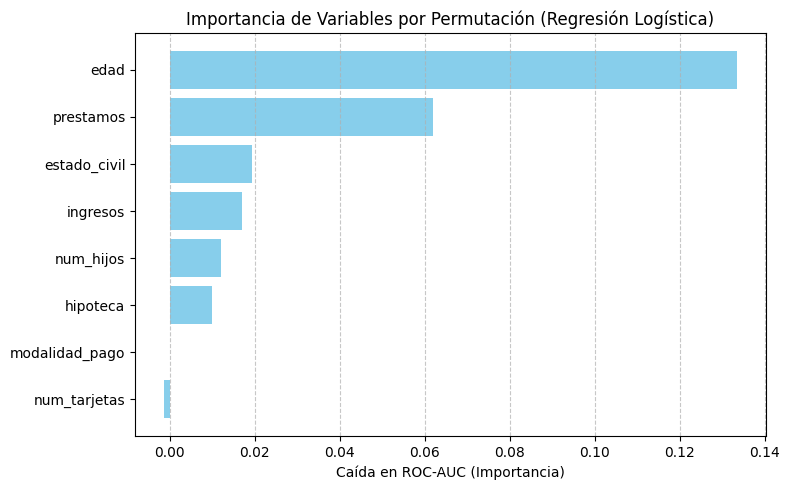

In [15]:
# Graficamos
plt.figure(figsize=(8, 5))
plt.barh(importancia['Variable'], importancia['Importancia'], color='skyblue')
plt.xlabel('Caída en ROC-AUC (Importancia)')
plt.title('Importancia de Variables por Permutación (Regresión Logística)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Random Forest

In [16]:
# Pipeline de preprocesamiento tress
num_cols = X.select_dtypes(['number']).columns.to_list()
cat_cols = X.select_dtypes(['str','category']).columns.to_list()

numerical_transformer_Trees = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))])

categorical_transformer_Trees = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor_Trees = ColumnTransformer(
    transformers=[
    ('num', numerical_transformer_Trees, num_cols),
    ('cat', categorical_transformer_Trees, cat_cols)],
    remainder='passthrough')

In [17]:
pipeline_RandomForest = Pipeline([
    ('preprocessor', preprocessor_Trees),
    ('classifier', RandomForestClassifier(random_state=seed, class_weight='balanced_subsample'))
])

In [18]:
param_grid_RandomForest = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [5, 10, None],
    'classifier__max_features': ['sqrt', 'log2', 0.5, 0.7],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}
random_forest = GridSearchCV(estimator= pipeline_RandomForest, 
                            param_grid= param_grid_RandomForest, 
                            cv= cv,
                            scoring='roc_auc',
                            n_jobs=-1)

In [19]:
random_forest.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [5, 10, ...], 'classifier__max_features': ['sqrt', 'log2', ...], 'classifier__min_samples_leaf': [1, 2, ...], 'classifier__min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplex

In [20]:
print(f"Mejores parámetros: {random_forest.best_params_}")

Mejores parámetros: {'classifier__max_depth': 5, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}


In [21]:
resultados_cv_RandomForest = pd.DataFrame(random_forest.cv_results_)
mejor_fila = resultados_cv_RandomForest.loc[random_forest.best_index_]

print(f"ROBUSTEZ DEL RANDOM FOREST (Basado en {random_forest.n_splits_} Folds)\n")
print(f"Rouc-Auc (Promedio): {mejor_fila['mean_test_score']:.2f}")
print(f"Desviación Estándar: {mejor_fila['std_test_score']:.2f}")

ROBUSTEZ DEL RANDOM FOREST (Basado en 5 Folds)

Rouc-Auc (Promedio): 0.77
Desviación Estándar: 0.01


Graficamos la curva roc sobre el conjunto de prueba

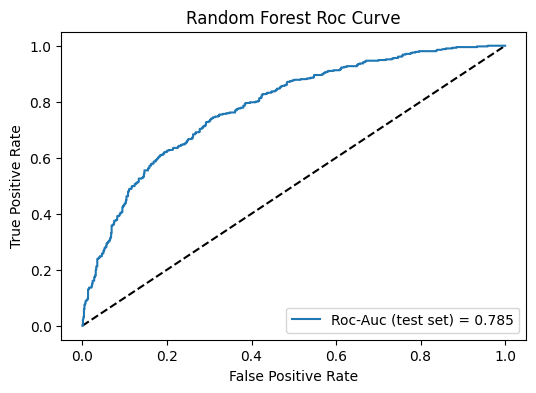

In [22]:
y_test_pred_probs = random_forest.predict_proba(X_test)[:,1]
fpr, tpr, umbrales = roc_curve(y_test, y_test_pred_probs)

plt.figure(figsize=(6,4))
plt.plot([0,1],[0,1],'k--')
plt.plot(fpr,tpr, label= f'Roc-Auc (test set) = {auc(fpr, tpr):.3f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest Roc Curve')
plt.legend(loc='lower right')
plt.show()

#### Feature Importance

Calculamos la importancia según el método de permutación

In [23]:
result = permutation_importance(
    random_forest.best_estimator_, 
    X_test, 
    y_test, 
    n_repeats=10, 
    random_state=seed, 
    scoring='roc_auc'
)

# Creamos el DataFrame con los resultados
importancia = pd.DataFrame({
    'Variable': X_test.columns,
    'Importancia': result.importances_mean
}).sort_values(by='Importancia', ascending=True)

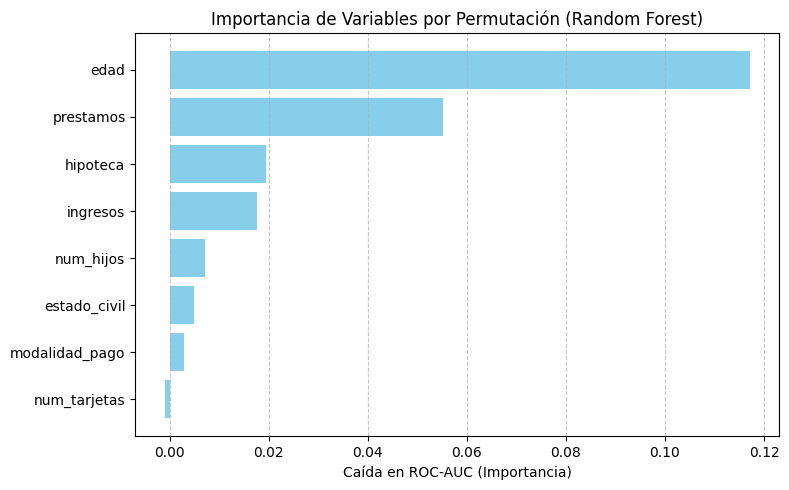

In [24]:
# Graficamos
plt.figure(figsize=(8, 5))
plt.barh(importancia['Variable'], importancia['Importancia'], color='skyblue')
plt.xlabel('Caída en ROC-AUC (Importancia)')
plt.title('Importancia de Variables por Permutación (Random Forest)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### XGBoost

In [25]:
# ratio para manejar el desbalance de clases
ratio_desbalance = y_train.value_counts()[0] / y_train.value_counts()[1]

In [26]:
pipeline_XGB = Pipeline([
    ('preprocessor', preprocessor_Trees),
    ('classifier', XGBClassifier(eval_metric='logloss', random_state=seed, scale_pos_weight=ratio_desbalance))
])

In [27]:
param_grid_XGB = {
    'classifier__n_estimators': [100, 200],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__max_depth': [3, 5, 7],  
    'classifier__subsample': [0.8, 1.0], 
    'classifier__colsample_bytree': [0.5,0.7],  
    'classifier__gamma': [0, 0.5, 1], 
}
xgboost = GridSearchCV(estimator= pipeline_XGB, 
                       param_grid= param_grid_XGB, 
                       cv= cv,
                       scoring= 'roc_auc',
                       n_jobs= -1)

In [28]:
xgboost.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__colsample_bytree': [0.5, 0.7], 'classifier__gamma': [0, 0.5, ...], 'classifier__learning_rate': [0.01, 0.05, ...], 'classifier__max_depth': [3, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross

In [29]:
print('Mejores Parámetros XGBoost: ',xgboost.best_params_)

Mejores Parámetros XGBoost:  {'classifier__colsample_bytree': 0.5, 'classifier__gamma': 1, 'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 100, 'classifier__subsample': 0.8}


In [30]:
resultados_cv_XGB = pd.DataFrame(xgboost.cv_results_)
mejor_fila_XGB = resultados_cv_XGB.loc[xgboost.best_index_]

print(f"ROBUSTEZ DEL XGBoost (Basado en {xgboost.n_splits_} Folds)\n")
print(f"Rouc-Auc (Promedio): {mejor_fila_XGB['mean_test_score']:.2f}")
print(f"Desviación Estándar: {mejor_fila_XGB['std_test_score']:.2f}")

ROBUSTEZ DEL XGBoost (Basado en 5 Folds)

Rouc-Auc (Promedio): 0.77
Desviación Estándar: 0.02


Graficamos la curva roc con el test-set

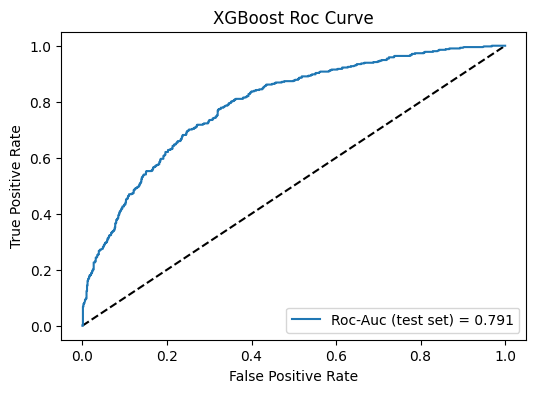

In [31]:
y_test_pred_probs = xgboost.predict_proba(X_test)[:,1]
fpr, tpr, umbrales = roc_curve(y_test, y_test_pred_probs)

plt.figure(figsize=(6,4))
plt.plot([0,1],[0,1],'k--')
plt.plot(fpr,tpr, label= f'Roc-Auc (test set) = {auc(fpr, tpr):.3f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost Roc Curve')
plt.legend(loc='lower right')
plt.show()

#### Feature Importance

In [32]:
result = permutation_importance(
    xgboost.best_estimator_, 
    X_test, 
    y_test, 
    n_repeats=10, 
    random_state=seed, 
    scoring='roc_auc'
)

# Creamos el DataFrame con los resultados
importancia = pd.DataFrame({
    'Variable': X_test.columns,
    'Importancia': result.importances_mean
}).sort_values(by='Importancia', ascending=True)

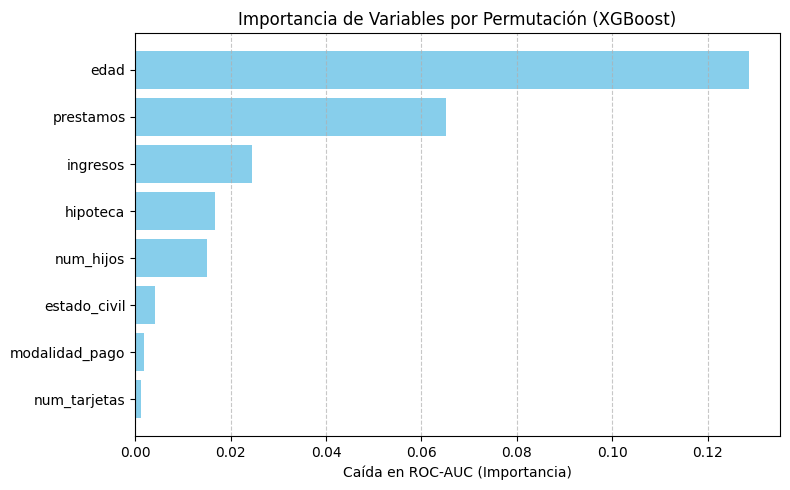

In [33]:
# Graficamos
plt.figure(figsize=(8, 5))
plt.barh(importancia['Variable'], importancia['Importancia'], color='skyblue')
plt.xlabel('Caída en ROC-AUC (Importancia)')
plt.title('Importancia de Variables por Permutación (XGBoost)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Desempeño de los modelos

In [34]:
y_pred_LogReg = logistic_model.predict(X_test)
report_LogReg = classification_report(y_test,y_pred_LogReg)
conf_matrix_LogReg = confusion_matrix(y_test, y_pred_LogReg).T

y_pred_RandomForest = random_forest.predict(X_test)
report_RandomForest = classification_report(y_test,y_pred_RandomForest)
conf_matrix_RandomForest = confusion_matrix(y_test, y_pred_RandomForest).T

y_pred_XGB = xgboost.predict(X_test)
report_XGB = classification_report(y_test,y_pred_XGB)
conf_matrix_XGB = confusion_matrix(y_test, y_pred_XGB).T

In [35]:
print('Regresión Logística\n',report_LogReg)
print('Random Forest\n',report_RandomForest)
print('XGBoost\n',report_XGB)

Regresión Logística
               precision    recall  f1-score   support

           0       0.83      0.71      0.76       825
           1       0.55      0.71      0.62       411

    accuracy                           0.71      1236
   macro avg       0.69      0.71      0.69      1236
weighted avg       0.74      0.71      0.71      1236

Random Forest
               precision    recall  f1-score   support

           0       0.82      0.72      0.77       825
           1       0.55      0.69      0.62       411

    accuracy                           0.71      1236
   macro avg       0.69      0.71      0.69      1236
weighted avg       0.73      0.71      0.72      1236

XGBoost
               precision    recall  f1-score   support

           0       0.84      0.73      0.78       825
           1       0.57      0.71      0.63       411

    accuracy                           0.72      1236
   macro avg       0.70      0.72      0.71      1236
weighted avg       0.75      

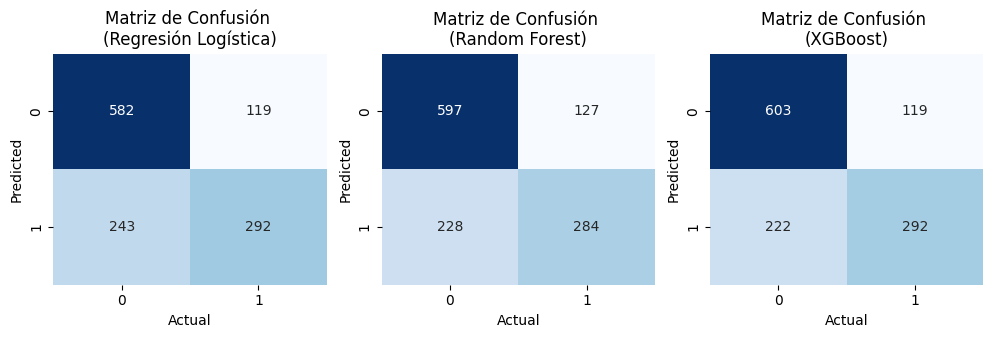

In [36]:
plt.figure(figsize=(12,3))

plt.subplot(1,3,1)
sns.heatmap(conf_matrix_LogReg, annot=True, cmap='Blues', fmt='d',cbar=False)
plt.title('Matriz de Confusión \n(Regresión Logística)')
plt.xlabel('Actual')
plt.ylabel('Predicted')

plt.subplot(1,3,2)
sns.heatmap(conf_matrix_RandomForest, annot=True, cmap='Blues', fmt='d',cbar=False)
plt.title('Matriz de Confusión \n(Random Forest)')
plt.xlabel('Actual')
plt.ylabel('Predicted')

plt.subplot(1,3,3)
sns.heatmap(conf_matrix_XGB, annot=True, cmap='Blues', fmt='d',cbar=False)
plt.title('Matriz de Confusión \n(XGBoost)')
plt.xlabel('Actual')
plt.ylabel('Predicted')

plt.show()

Se evidencia que el XGBoost presenta el mejor desempeño global entre los tres algoritmos evaluados. Aunque comparte el mismo Recall (0.71) para la clase de riesgo que la Regresión Logística, el XGBoost demuestra una superioridad cuantitativa al lograr una mayor precisión reduciendo así el número de falsos positivos. Esto se traduce en un F1-Score ponderado de 0.73, ofreciendo el equilibrio más eficiente entre la mitigación del riesgo y la maximización de la tasa de aprobación para clientes aptos. Por lo tanto, se selecciona este modelo para la fase de despliegue.